# Baseline Model Building & Hyperparameter Tuning

In [ ]:
#pip install scikit-multilearn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#pip install iterative-stratification

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.


In [4]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, recall_score, hamming_loss, precision_score
import lightgbm as lgb
from lightgbm import LGBMClassifier
import time
import pandas as pd
import joblib
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
import os

SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✓ Models will be saved to: {SAVE_DIR}")

✓ Models will be saved to: /kaggle/working/models


# Preparing data

In [9]:
import json

with open("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/feature_cols.json", "r") as f:
    feature_cols = json.load(f)

with open("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/reaction_cols.json", "r") as f:
    reaction_cols = json.load(f)

with open("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/drug_cols.json", "r") as f:
    drug_cols = json.load(f)

print(f"Feature columns ({len(feature_cols)}): {feature_cols}...")
print(f"Reaction columns ({len(reaction_cols)}): {reaction_cols}")
print(f"Reaction columns ({len(drug_cols)}): {drug_cols}")

Feature columns (14): ['age_yrs_clean', 'num_drugs', 'sex_encoded', 'country_freq_encoded', 'drug_PREDNISONE', 'drug_DUPILUMAB', 'drug_RITUXIMAB', 'drug_METHOTREXATE', 'drug_INFLIXIMAB-DYYB', 'drug_VEDOLIZUMAB', 'drug_ACETAMINOPHEN', 'drug_TIRZEPATIDE', 'drug_TOCILIZUMAB', 'drug_INFLIXIMAB']...
Reaction columns (10): ['reaction_DIARRHOEA', 'reaction_RASH', 'reaction_NAUSEA', 'reaction_DYSPNOEA', 'reaction_INFECTION', 'reaction_PSYCHIATRIC_EVENT', 'reaction_FATIGUE', 'reaction_DEATH', 'reaction_INJECTION_SITE_REACTION', 'reaction_HEADACHE']
Reaction columns (10): ['drug_PREDNISONE', 'drug_DUPILUMAB', 'drug_RITUXIMAB', 'drug_METHOTREXATE', 'drug_INFLIXIMAB-DYYB', 'drug_VEDOLIZUMAB', 'drug_ACETAMINOPHEN', 'drug_TIRZEPATIDE', 'drug_TOCILIZUMAB', 'drug_INFLIXIMAB']


In [10]:
X_train        = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_train.npy")
X_train_scaled = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_train_scaled.npy")
X_val          = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_val.npy")
X_val_scaled   = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_val_scaled.npy")
X_test         = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_test.npy")
X_test_scaled  = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/X_test_scaled.npy")

y_test         = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/y_test.npy")
y_train        = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/y_train.npy")
y_val          = np.load("/kaggle/input/datasets/alyssandra14/split-data-and-json-col-with-rf-imputer/y_val.npy")

In [12]:
# ── Class weights per reaction (for imbalance handling) ───────────
print(f"\nClass imbalance ratios (neg/pos):")
scale_pos_weight = {}
for i, col in enumerate(reaction_cols):
    pos = y_train[:, i].sum()
    neg = len(y_train) - pos
    ratio = neg / pos if pos > 0 else 999
    scale_pos_weight[col] = ratio
    print(f"  {col:<35} {ratio:>8.1f}x")


Class imbalance ratios (neg/pos):
  reaction_DIARRHOEA                       7.1x
  reaction_RASH                            4.1x
  reaction_NAUSEA                          6.4x
  reaction_DYSPNOEA                        8.6x
  reaction_INFECTION                       3.7x
  reaction_PSYCHIATRIC_EVENT              10.5x
  reaction_FATIGUE                         6.7x
  reaction_DEATH                          28.5x
  reaction_INJECTION_SITE_REACTION         2.7x
  reaction_HEADACHE                        8.3x


In [13]:
with open("scale_pos_weight.json", "w") as f:
    json.dump(scale_pos_weight, f, indent=4)

### Base Model Building

- Logistic Regression
- Decision Tree
- Random Forest
- LightBGM
- XGBoost (MultiClassifier Version)
- XGBoost (Per weighted reaction)

In [14]:
# new updated threshold
from sklearn.metrics import precision_recall_curve
def best_threshold_f2(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    beta = 2
    f2_scores = (1 + beta**2) * (precision * recall) / (
        (beta**2 * precision) + recall + 1e-9
    )

    # Align with thresholds (exclude last point)
    f2_scores  = f2_scores[:-1]
    precision  = precision[:-1]
    recall     = recall[:-1]

    best_idx = np.argmax(f2_scores)
    return (
        thresholds[best_idx],
        f2_scores[best_idx],
        precision[best_idx],
        recall[best_idx],
    )

In [15]:
def evaluate_model_val(model, X, y, reaction_cols, model_name, mode="multi"):
    print(f"\n{'═'*70}")
    print(f"  {model_name} — Validation Set (AP / AUC only)")
    print(f"{'═'*70}")
    print(f"  {'Reaction':<35} {'AP':>6} {'ROC-AUC':>6}")
    print(f"  {'─'*50}")

    aps, roc_aucs = [], []

    if mode == "multi":
        all_probs = model.predict_proba(X)

    for i, col in enumerate(reaction_cols):
        y_true  = y[:, i]
        y_prob  = all_probs[i][:, 1] if mode == "multi" else model[col].predict_proba(X)[:, 1]

        ap      = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)

        aps.append(ap)
        roc_aucs.append(roc_auc)

        print(f"  {col:<35} {ap:>6.4f} {roc_auc:>6.4f}")

    print(f"  {'─'*50}")
    print(f"  {'AVERAGE (Macro)':<35} {np.mean(aps):>6.4f} {np.mean(roc_aucs):>6.4f}")
    print(f"{'═'*70}")

    return {"AP": np.mean(aps), "ROC-AUC": np.mean(roc_aucs)}

In [16]:
def evaluate_model_test(model, X, y, reaction_cols, model_name, thresholds, mode="multi"):
    """
    mode options:
        "multi"  — sklearn MultiOutputClassifier (LR, RF, DT, XGBoost wrapped)
        "loop"   — dict of per-label models, keyed by col name (XGB loop)
        "lgbm"   — LightGBM MultiOutputClassifier or native multi-output
    """
    print(f"\n{'═'*90}")
    print(f"  {model_name} — Test Set Evaluation")
    print(f"{'═'*90}")
    print(f"  {'Reaction':<35} {'AP':>6} {'ROC-AUC':>6} {'F2':>6} {'Prec':>6} {'Recall':>6} {'Thr':>6}")
    print(f"  {'─'*85}")

    aps, roc_aucs, f2s, precs, recalls = [], [], [], [], []
    all_y_pred = []

    # ── Pre-compute probabilities where possible ───────────────────────────────
    if mode in ("multi", "lgbm"):
        # predict_proba returns a list of (n, 2) arrays, one per label
        all_probs = model.predict_proba(X)

    for i, col in enumerate(reaction_cols):
        y_true = y[:, i]

        # ── Per-mode probability extraction ───────────────────────────────────
        if mode == "multi":
            # LR / RF / DT / XGBoost wrapped in MultiOutputClassifier
            prob = all_probs[i]
            y_prob = prob[:, 1] if prob.ndim == 2 else prob

        elif mode == "lgbm":
            # LightGBM via MultiOutputClassifier
            prob = all_probs[i]
            y_prob = prob[:, 1] if prob.ndim == 2 else prob

        elif mode == "loop":
            # XGB trained label-by-label, stored in a dict keyed by col
            y_prob = model[col].predict_proba(X)[:, 1]

        else:
            raise ValueError(f"Unknown mode '{mode}'. Choose from: 'multi', 'loop', 'lgbm'.")

        thr    = thresholds[i]
        y_pred = (y_prob >= thr).astype(int)
        all_y_pred.append(y_pred)

        ap      = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)

        beta = 2
        p  = precision_score(y_true, y_pred, zero_division=0)
        r  = recall_score(y_true, y_pred, zero_division=0)
        f2 = (1 + beta**2) * p * r / ((beta**2 * p) + r + 1e-9)

        aps.append(ap);  roc_aucs.append(roc_auc)
        f2s.append(f2);  precs.append(p);  recalls.append(r)

        print(f"  {col:<35} {ap:>6.4f} {roc_auc:>6.4f} {f2:>6.4f} {p:>6.4f} {r:>6.4f} {thr:>6.2f}")

    all_y_pred = np.array(all_y_pred).T
    h_loss     = hamming_loss(y, all_y_pred)

    print(f"  {'─'*85}")
    print(f"  {'AVERAGE (Macro)':<35} {np.mean(aps):>6.4f} {np.mean(roc_aucs):>6.4f} {np.mean(f2s):>6.4f} {np.mean(precs):>6.4f} {np.mean(recalls):>6.4f}")
    print(f"  {'Hamming Loss (Lower is better)':<35} {h_loss:>6.4f}")
    print(f"{'═'*90}")

    return {
        "AP": np.mean(aps), "ROC-AUC": np.mean(roc_aucs),
        "F2": np.mean(f2s), "Precision": np.mean(precs),
        "Recall": np.mean(recalls), "HammingLoss": h_loss
    }
# ══════════════════════════════════════════════

In [17]:
# ════════════════════════════════════════════════════════════════
# MODEL 1 — LOGISTIC REGRESSION
# ════════════════════════════════════════════════════════════════

print("Training Logistic Regression...")
start = time.time()

model_lr = MultiOutputClassifier(
    LogisticRegression(
        class_weight = "balanced",
        max_iter     = 1000,
        solver       = "lbfgs",
        random_state = 42,
        n_jobs       = -1
    ),
    n_jobs=-1
)
model_lr.fit(X_train_scaled, y_train)

print(f"✓ Done in {time.time()-start:.1f}s")
results_lr = evaluate_model_val(model_lr, X_val_scaled, y_val, reaction_cols,
                             "Logistic Regression", mode="multi")

Training Logistic Regression...
✓ Done in 3.9s

══════════════════════════════════════════════════════════════════════
  Logistic Regression — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.2734 0.7322
  reaction_RASH                       0.3987 0.7452
  reaction_NAUSEA                     0.2691 0.7396
  reaction_DYSPNOEA                   0.2064 0.7117
  reaction_INFECTION                  0.5018 0.7950
  reaction_PSYCHIATRIC_EVENT          0.2279 0.7448
  reaction_FATIGUE                    0.2843 0.7209
  reaction_DEATH                      0.1275 0.8003
  reaction_INJECTION_SITE_REACTION    0.4873 0.7766
  reaction_HEADACHE                   0.2376 0.7046
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3014 0.7471
════════════════════════

In [18]:
# ════════════════════════════════════════════════════════════════
# MODEL 2 — DECISION TREE
# ════════════════════════════════════════════════════════════════

print("\nTraining Decision Tree...")
start = time.time()

model_dt = MultiOutputClassifier(
    DecisionTreeClassifier(
        class_weight = "balanced",
        max_depth    = 10,        # limit depth to reduce overfitting
        min_samples_split = 20,   # minimum samples to split a node
        min_samples_leaf  = 10,   # minimum samples at leaf node
        random_state = 42
    ),
    n_jobs=-1
)
model_dt.fit(X_train, y_train)

print(f"✓ Done in {time.time()-start:.1f}s")
results_dt = evaluate_model_val(model_dt, X_val, y_val, reaction_cols,
                             "Decision Tree", mode="multi")


Training Decision Tree...
✓ Done in 0.7s

══════════════════════════════════════════════════════════════════════
  Decision Tree — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3038 0.7430
  reaction_RASH                       0.4228 0.7575
  reaction_NAUSEA                     0.3061 0.7494
  reaction_DYSPNOEA                   0.2601 0.7318
  reaction_INFECTION                  0.5446 0.8112
  reaction_PSYCHIATRIC_EVENT          0.3561 0.7746
  reaction_FATIGUE                    0.3103 0.7370
  reaction_DEATH                      0.1480 0.7967
  reaction_INJECTION_SITE_REACTION    0.5420 0.8052
  reaction_HEADACHE                   0.3004 0.7311
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3494 0.7638
═══════════════════════════════════

In [19]:
# ════════════════════════════════════════════════════════════════
# MODEL 3 — RANDOM FOREST
# ════════════════════════════════════════════════════════════════

print("\nTraining Random Forest...")
start = time.time()

model_rf = MultiOutputClassifier(
    RandomForestClassifier(
        class_weight = "balanced",
        n_estimators = 200,
        max_depth    = 15,
        min_samples_split = 20,
        min_samples_leaf  = 10,
        random_state = 42,
        n_jobs       = -1
    ),
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

print(f"✓ Done in {time.time()-start:.1f}s")
results_rf = evaluate_model_val(model_rf, X_val, y_val, reaction_cols,
                             "Random Forest", mode="multi")


Training Random Forest...
✓ Done in 34.3s

══════════════════════════════════════════════════════════════════════
  Random Forest — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3354 0.7676
  reaction_RASH                       0.4380 0.7654
  reaction_NAUSEA                     0.3393 0.7658
  reaction_DYSPNOEA                   0.3128 0.7556
  reaction_INFECTION                  0.5741 0.8198
  reaction_PSYCHIATRIC_EVENT          0.3753 0.7951
  reaction_FATIGUE                    0.3385 0.7483
  reaction_DEATH                      0.1746 0.8317
  reaction_INJECTION_SITE_REACTION    0.5459 0.8069
  reaction_HEADACHE                   0.3200 0.7383
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3754 0.7794
══════════════════════════════════

In [20]:
# ════════════════════════════════════════════════════════════════
# MODEL 5 — LightGBM (MultiOutput)
# ════════════════════════════════════════════════════════════════
print("\nTraining LightGBM (MultiOutput)...")
start = time.time()

model_lgbm = MultiOutputClassifier(
    LGBMClassifier(
        class_weight  = "balanced",
        n_estimators  = 300,
        max_depth     = 6,
        learning_rate = 0.05,
        subsample     = 0.8,
        colsample_bytree = 0.8,
        random_state  = 42,
        n_jobs        = 1,
        verbosity     = -1,   # suppress output
    ),
    n_jobs=-1
)

X_train_df = pd.DataFrame(X_train, columns=feature_cols)
model_lgbm.fit(X_train_df, y_train)

print(f"✓ Done in {time.time()-start:.1f}s")
results_lgbm = evaluate_model_val(model_lgbm, X_val, y_val, reaction_cols,
                                  "LightGBM (MultiOutput)", mode="multi")


Training LightGBM (MultiOutput)...
✓ Done in 17.0s

══════════════════════════════════════════════════════════════════════
  LightGBM (MultiOutput) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3352 0.7644
  reaction_RASH                       0.4309 0.7626
  reaction_NAUSEA                     0.3319 0.7633
  reaction_DYSPNOEA                   0.3036 0.7539
  reaction_INFECTION                  0.5607 0.8182
  reaction_PSYCHIATRIC_EVENT          0.3467 0.7910
  reaction_FATIGUE                    0.3289 0.7485
  reaction_DEATH                      0.1836 0.8301
  reaction_INJECTION_SITE_REACTION    0.5481 0.8072
  reaction_HEADACHE                   0.3089 0.7371
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3679 0.7776
════════════════

In [21]:
# ════════════════════════════════════════════════════════════════
# MODEL 4A — XGBOOST (MultiOutputClassifier — simple version)
# ════════════════════════════════════════════════════════════════

print("\nTraining XGBoost (MultiOutputClassifier)...")
start = time.time()

avg_spw = np.mean(list(scale_pos_weight.values()))
print(f"  Using average scale_pos_weight: {avg_spw:.1f}x")

model_xgb_multi = MultiOutputClassifier(
    XGBClassifier(
        scale_pos_weight     = avg_spw,
        n_estimators         = 300,
        max_depth            = 6,
        learning_rate        = 0.05,
        subsample            = 0.8,
        colsample_bytree     = 0.8,
        eval_metric          = "aucpr",
        random_state         = 42,
        n_jobs               = 1,
        verbosity            = 0,
        device               = "cuda",
    ),
    n_jobs=-1
)
model_xgb_multi.fit(X_train, y_train)

print(f"✓ Done in {time.time()-start:.1f}s")
results_xgb_multi = evaluate_model_val(model_xgb_multi, X_val, y_val, reaction_cols,
                                    "XGBoost (MultiOutput)", mode="multi")


Training XGBoost (MultiOutputClassifier)...
  Using average scale_pos_weight: 8.7x
✓ Done in 8.5s

══════════════════════════════════════════════════════════════════════
  XGBoost (MultiOutput) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3418 0.7693
  reaction_RASH                       0.4384 0.7661
  reaction_NAUSEA                     0.3450 0.7666
  reaction_DYSPNOEA                   0.3113 0.7564
  reaction_INFECTION                  0.5711 0.8202
  reaction_PSYCHIATRIC_EVENT          0.3808 0.7937
  reaction_FATIGUE                    0.3438 0.7499
  reaction_DEATH                      0.1916 0.8351
  reaction_INJECTION_SITE_REACTION    0.5495 0.8078
  reaction_HEADACHE                   0.3244 0.7395
  ──────────────────────────────────────────────────
  AVERAGE (Macro)     

In [ ]:
# ════════════════════════════════════════════════════════════════
# MODEL 4B — XGBOOST (Loop — per-reaction weight version)
# ════════════════════════════════════════════════════════════════

print("\nTraining XGBoost (Loop — per-reaction weights)...")
start = time.time()

model_xgb_loop = {}

for i, col in enumerate(reaction_cols):
    spw = scale_pos_weight[col]

    clf = XGBClassifier(
        scale_pos_weight = spw,
        n_estimators     = 300,
        max_depth         = 6,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        eval_metric       = "aucpr",
        random_state      = 42,
        n_jobs            = 1,
        verbosity         = 0,
        device            = "cuda",
    )

    clf.fit(
        X_train, y_train[:, i]   # no eval_set, no early_stopping_rounds
    )

    model_xgb_loop[col] = clf
    print(f"  ✓ {col:<35} spw={spw:.1f}x")

print(f"\n✓ All 10 XGBoost models done in {time.time()-start:.1f}s")
results_xgb_loop = evaluate_model_val(model_xgb_loop, X_val, y_val, reaction_cols,
                                        "XGBoost (Loop)", mode="loop")


Training XGBoost (Loop — per-reaction weights)...
  ✓ reaction_DIARRHOEA                  spw=7.1x  best_iteration=299
  ✓ reaction_RASH                       spw=4.1x  best_iteration=299
  ✓ reaction_NAUSEA                     spw=6.4x  best_iteration=296
  ✓ reaction_DYSPNOEA                   spw=8.6x  best_iteration=288
  ✓ reaction_INFECTION                  spw=3.7x  best_iteration=299
  ✓ reaction_PSYCHIATRIC_EVENT          spw=10.5x  best_iteration=299
  ✓ reaction_FATIGUE                    spw=6.7x  best_iteration=294
  ✓ reaction_DEATH                      spw=28.5x  best_iteration=101
  ✓ reaction_INJECTION_SITE_REACTION    spw=2.7x  best_iteration=89
  ✓ reaction_HEADACHE                   spw=8.3x  best_iteration=297

✓ All 10 XGBoost models done in 6.9s

══════════════════════════════════════════════════════════════════════
  XGBoost (Loop) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                 

In [23]:
# ════════════════════════════════════════════════════════════════
# SECTION 5 — COMPARE ALL BASE MODELS
# ════════════════════════════════════════════════════════════════
print("\n")
print("═" * 60)
print("  BASE MODEL COMPARISON — Validation Set (AP / AUC only)")
print("═" * 60)
print(f"  {'Model':<25} {'Avg AP':>8} {'Avg AUC':>8}")
print(f"  {'─'*45}")

all_results = {
    "Logistic Regression"  : results_lr,
    "Decision Tree"        : results_dt,        # ← added back
    "Random Forest"        : results_rf,
    "LightGBM"             : results_lgbm,
    "XGBoost (MultiOutput)": results_xgb_multi,
    "XGBoost (Loop)"       : results_xgb_loop,
}

for name, res in sorted(all_results.items(), key=lambda x: -x[1]["AP"]):
    print(f"  {name:<25} {res['AP']:>8.4f} {res['ROC-AUC']:>8.4f}")

print("═" * 60)



════════════════════════════════════════════════════════════
  BASE MODEL COMPARISON — Validation Set (AP / AUC only)
════════════════════════════════════════════════════════════
  Model                       Avg AP  Avg AUC
  ─────────────────────────────────────────────
  XGBoost (MultiOutput)       0.3798   0.7805
  XGBoost (Loop)              0.3795   0.7805
  Random Forest               0.3754   0.7794
  LightGBM                    0.3679   0.7776
  Decision Tree               0.3494   0.7638
  Logistic Regression         0.3014   0.7471
════════════════════════════════════════════════════════════


# Hyperparameter Tuning

In [24]:
# setting constant cross validation
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [25]:
# ════════════════════════════════════════════════════════════════
# SECTION 6 — BAYESIAN HYPERPARAMETER TUNING
# ════════════════════════════════════════════════════════════════
def macro_ap_scorer(estimator, X, y):
    aps = []
    y_probs = estimator.predict_proba(X)
    for i in range(y.shape[1]):
        y_prob = y_probs[i][:, 1] if isinstance(y_probs, list) else y_probs[:, i]
        if len(np.unique(y[:, i])) < 2:
            continue
        aps.append(average_precision_score(y[:, i], y_prob))
    return np.mean(aps)  # equal weighting — severity handled later


# ── Validation curve helper ───────────────────────────────────────
def plot_validation_curves(search_result, model_name):
    results    = search_result.cv_results_
    iterations = np.arange(1, len(results["mean_test_score"]) + 1)
    mean_val   = results["mean_test_score"]
    std_val    = results["std_test_score"]
    mean_train = results["mean_train_score"]
    std_train  = results["std_train_score"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Bayesian Tuning Validation Curves", fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.plot(iterations, mean_val,   label="Val AP",   color="steelblue")
    ax.fill_between(iterations, mean_val - std_val,   mean_val + std_val,   alpha=0.2, color="steelblue")
    ax.plot(iterations, mean_train, label="Train AP", color="coral", linestyle="--")
    ax.fill_between(iterations, mean_train - std_train, mean_train + std_train, alpha=0.2, color="coral")
    ax.axvline(np.argmax(mean_val) + 1, color="green", linestyle=":", label=f"Best iter={np.argmax(mean_val)+1}")
    ax.set_xlabel("Bayesian Iteration")
    ax.set_ylabel("Macro AP")                              # ← changed
    ax.set_title("AP per Iteration")                       # ← changed
    ax.legend()
    ax.grid(True, alpha=0.3)

    gap = mean_train - mean_val
    ax  = axes[1]
    ax.plot(iterations, gap, color="purple")
    ax.fill_between(iterations, 0, gap, alpha=0.15, color="purple")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Bayesian Iteration")
    ax.set_ylabel("Train AP − Val AP")                     # ← changed
    ax.set_title("Overfitting Gap (lower = better generalisation)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"val_curve_{model_name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Saved: val_curve_{model_name.replace(' ', '_')}.png")

    # ── Print overfitting summary ──
    best_idx       = np.argmax(mean_val)
    best_val_ap    = mean_val[best_idx]
    best_train_ap  = mean_train[best_idx]
    best_gap       = gap[best_idx]
    avg_gap        = np.mean(gap)
    max_gap        = np.max(gap)

    print(f"  ── Overfitting Summary ──")
    print(f"  Best iter={best_idx+1}  |  Train AP={best_train_ap:.4f}  |  Val AP={best_val_ap:.4f}  |  Gap={best_gap:.4f}")
    print(f"  Avg gap={avg_gap:.4f}  |  Max gap={max_gap:.4f}")

Tuning Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

  Best AP: 0.3003  |  Best params: OrderedDict({'estimator__C': 0.12172976749510152, 'estimator__max_iter': 3326, 'estimator__solver': 'lbfgs', 'estimator__tol': 0.005605967693796125})


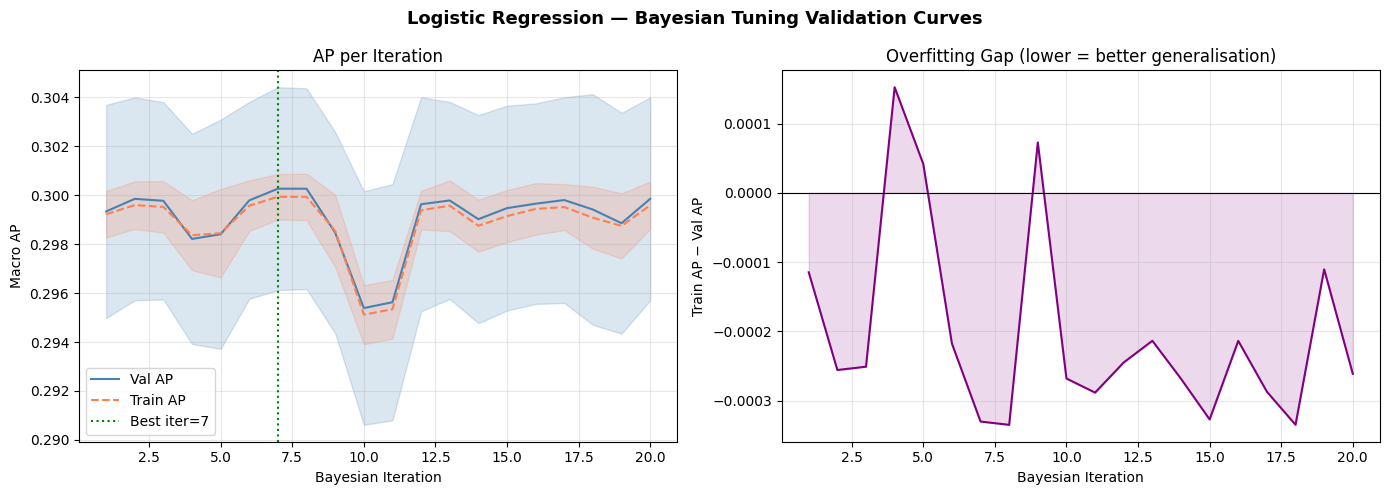

  ✓ Saved: val_curve_Logistic_Regression.png
  ── Overfitting Summary ──
  Best iter=7  |  Train AP=0.2999  |  Val AP=0.3003  |  Gap=-0.0003
  Avg gap=-0.0002  |  Max gap=0.0002


In [ ]:
# ════════════════════════════════════════════════════════════════
# TUNING 1 — LOGISTIC REGRESSION
# ════════════════════════════════════════════════════════════════
print("Tuning Logistic Regression...")

search_lr = BayesSearchCV(
    MultiOutputClassifier(LogisticRegression(class_weight="balanced", random_state=42, n_jobs=-1)),
    {
        "estimator__C":        Real(1e-4, 10.0, prior="log-uniform"),
        "estimator__solver":   Categorical(["lbfgs", "newton-cg"]),
        "estimator__max_iter": Integer(1000, 4000),
        "estimator__tol": Real(1e-4, 1e-2, prior="log-uniform")
    },
    n_iter=20, cv=mskf, scoring=macro_ap_scorer,
    return_train_score=True, random_state=42, n_jobs=-1, verbose=0
)
search_lr.fit(X_train_scaled, y_train)
print(f"  Best AP: {search_lr.best_score_:.4f}  |  Best params: {search_lr.best_params_}")
plot_validation_curves(search_lr, "Logistic Regression")

In [27]:
results_lr_tuned = evaluate_model_val(search_lr.best_estimator_, X_val_scaled, y_val, reaction_cols, "LR (Tuned)",  mode="multi")


══════════════════════════════════════════════════════════════════════
  LR (Tuned) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.2744 0.7328
  reaction_RASH                       0.4004 0.7453
  reaction_NAUSEA                     0.2690 0.7396
  reaction_DYSPNOEA                   0.2067 0.7118
  reaction_INFECTION                  0.5016 0.7955
  reaction_PSYCHIATRIC_EVENT          0.2289 0.7449
  reaction_FATIGUE                    0.2845 0.7209
  reaction_DEATH                      0.1275 0.8004
  reaction_INJECTION_SITE_REACTION    0.4891 0.7770
  reaction_HEADACHE                   0.2377 0.7064
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3020 0.7475
══════════════════════════════════════════════════════════════════════


In [28]:
# save model
joblib.dump(search_lr.best_estimator_, f"{SAVE_DIR}/lr_model.pkl")

['/kaggle/working/models/lr_model.pkl']


Tuning Decision Tree...
  Best AP: 0.3548  |  Best params: OrderedDict({'estimator__criterion': 'entropy', 'estimator__max_depth': 20, 'estimator__max_features': None, 'estimator__min_samples_leaf': 20, 'estimator__min_samples_split': 51})


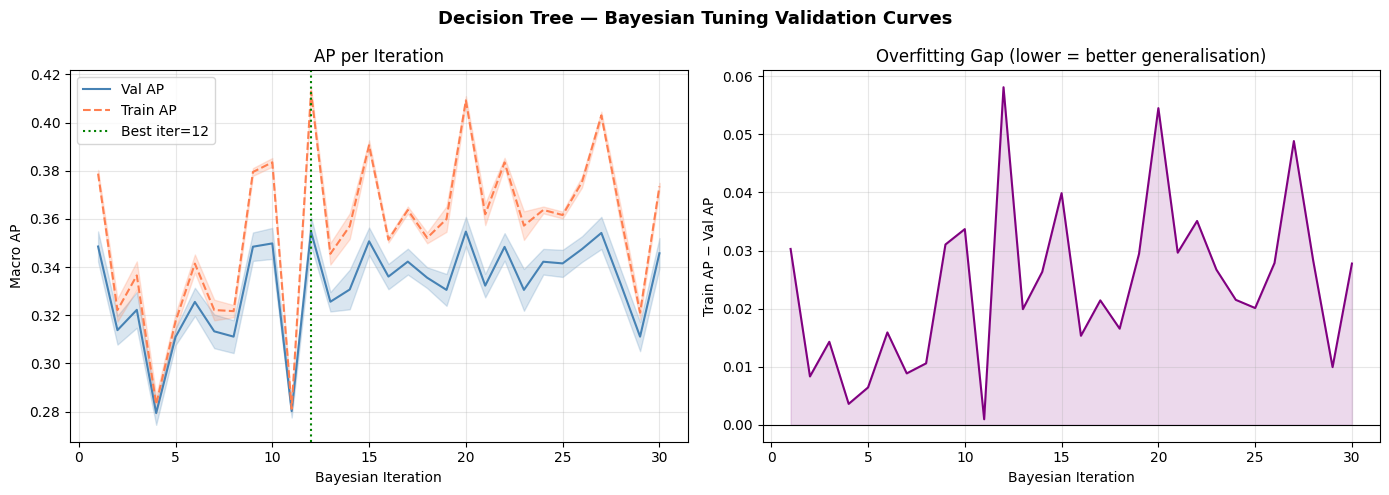

  ✓ Saved: val_curve_Decision_Tree.png
  ── Overfitting Summary ──
  Best iter=12  |  Train AP=0.4129  |  Val AP=0.3548  |  Gap=0.0581
  Avg gap=0.0240  |  Max gap=0.0581


In [29]:
#════════════════════════════════════════════════════════════════
#TUNING 2 — DECISION TREE
#════════════════════════════════════════════════════════════════
print("\nTuning Decision Tree...")

search_dt = BayesSearchCV(
    MultiOutputClassifier(DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    {
        "estimator__max_depth":         Integer(3, 20),
        "estimator__min_samples_split": Integer(50, 200),
        "estimator__min_samples_leaf":  Integer(20, 100),
        "estimator__max_features":      Categorical(["sqrt", "log2", None]),
        "estimator__criterion":         Categorical(["gini", "entropy"]),
    },
    n_iter=30, cv=mskf, scoring=macro_ap_scorer,
    return_train_score=True, random_state=42, n_jobs=-1, verbose=0
)
search_dt.fit(X_train, y_train)
print(f"  Best AP: {search_dt.best_score_:.4f}  |  Best params: {search_dt.best_params_}")
plot_validation_curves(search_dt, "Decision Tree")

In [30]:
results_dt_tuned = evaluate_model_val(search_dt.best_estimator_, X_val, y_val, reaction_cols, "DT (Tuned)",  mode="multi")


══════════════════════════════════════════════════════════════════════
  DT (Tuned) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3261 0.7545
  reaction_RASH                       0.4249 0.7575
  reaction_NAUSEA                     0.3228 0.7517
  reaction_DYSPNOEA                   0.2936 0.7385
  reaction_INFECTION                  0.5559 0.8113
  reaction_PSYCHIATRIC_EVENT          0.3674 0.7781
  reaction_FATIGUE                    0.3275 0.7334
  reaction_DEATH                      0.1569 0.7746
  reaction_INJECTION_SITE_REACTION    0.5414 0.8025
  reaction_HEADACHE                   0.3044 0.7212
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3621 0.7623
══════════════════════════════════════════════════════════════════════


In [31]:
joblib.dump(search_dt.best_estimator_, f"{SAVE_DIR}/dt_model.pkl")

['/kaggle/working/models/dt_model.pkl']


Tuning Random Forest...
  Best AP: 0.3756  |  Best params: OrderedDict({'estimator__max_depth': 15, 'estimator__max_features': 'log2', 'estimator__min_samples_leaf': 5, 'estimator__min_samples_split': 10, 'estimator__n_estimators': 300})


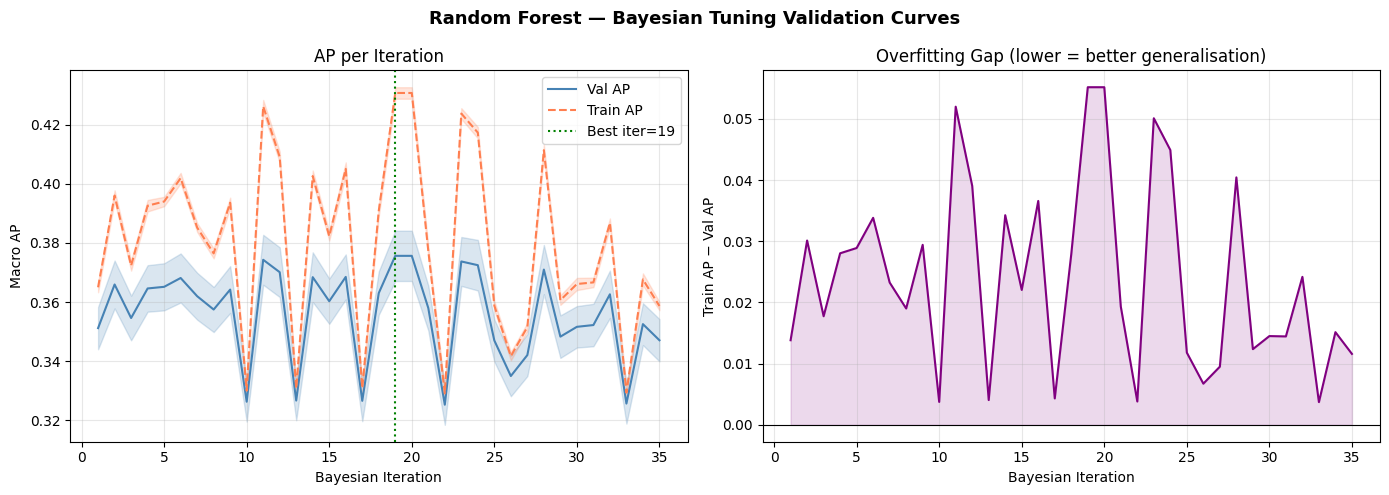

  ✓ Saved: val_curve_Random_Forest.png
  ── Overfitting Summary ──
  Best iter=19  |  Train AP=0.4308  |  Val AP=0.3756  |  Gap=0.0552
  Avg gap=0.0240  |  Max gap=0.0552


In [ ]:
# ════════════════════════════════════════════════════════════════
# TUNING 3 — RANDOM FOREST
# ════════════════════════════════════════════════════════════════
print("\nTuning Random Forest...")
search_rf = BayesSearchCV(
    MultiOutputClassifier(RandomForestClassifier(class_weight="balanced", random_state=42)),
    {
        "estimator__n_estimators":      Integer(100, 300),
        "estimator__max_depth":         Integer(5, 15),          
        "estimator__min_samples_split": Integer(10, 50),         
        "estimator__min_samples_leaf":  Integer(5, 20),         
        "estimator__max_features":      Categorical(["sqrt", "log2"]),
    },
    n_iter=35, cv=mskf, scoring=macro_ap_scorer,
    return_train_score=True, random_state=42, n_jobs=-1, verbose=0
)
search_rf.fit(X_train, y_train)
print(f"  Best AP: {search_rf.best_score_:.4f}  |  Best params: {search_rf.best_params_}")
plot_validation_curves(search_rf, "Random Forest")

In [33]:
results_rf_tuned = evaluate_model_val(search_rf.best_estimator_, X_val, y_val, reaction_cols, "RF (Tuned)",  mode="multi")


══════════════════════════════════════════════════════════════════════
  RF (Tuned) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3424 0.7697
  reaction_RASH                       0.4411 0.7668
  reaction_NAUSEA                     0.3454 0.7675
  reaction_DYSPNOEA                   0.3218 0.7583
  reaction_INFECTION                  0.5822 0.8211
  reaction_PSYCHIATRIC_EVENT          0.3851 0.7944
  reaction_FATIGUE                    0.3459 0.7489
  reaction_DEATH                      0.1751 0.8244
  reaction_INJECTION_SITE_REACTION    0.5465 0.8072
  reaction_HEADACHE                   0.3265 0.7401
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3812 0.7798
══════════════════════════════════════════════════════════════════════


In [34]:
joblib.dump(search_rf.best_estimator_, f"{SAVE_DIR}/rf_model.pkl")

['/kaggle/working/models/rf_model.pkl']


Tuning LightGBM (MultiOutput)...
  Best AP: 0.3716  |  Best params: OrderedDict({'estimator__colsample_bytree': 0.85, 'estimator__learning_rate': 0.1, 'estimator__max_depth': 7, 'estimator__min_child_samples': 20, 'estimator__n_estimators': 480, 'estimator__num_leaves': 60, 'estimator__reg_alpha': 1.569909040299249, 'estimator__reg_lambda': 1.0, 'estimator__subsample': 0.9})


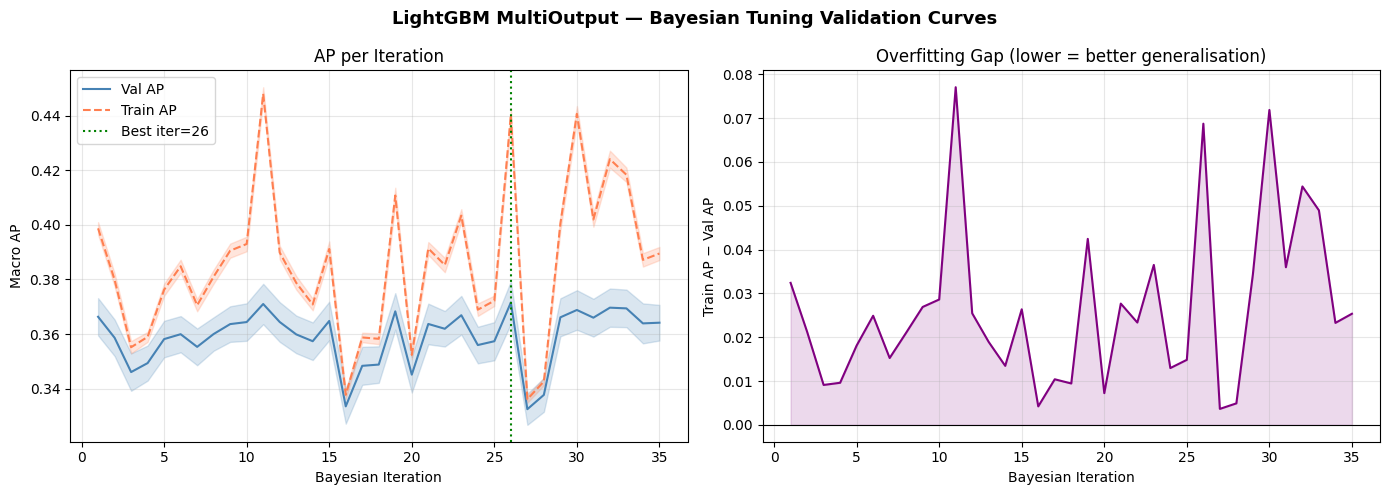

  ✓ Saved: val_curve_LightGBM_MultiOutput.png
  ── Overfitting Summary ──
  Best iter=26  |  Train AP=0.4403  |  Val AP=0.3716  |  Gap=0.0687
  Avg gap=0.0265  |  Max gap=0.0770


In [ ]:
# ════════════════════════════════════════════════════════════════
# TUNING 4 — LightGBM (MultiOutput)
# ════════════════════════════════════════════════════════════════
print("\nTuning LightGBM (MultiOutput)...")
search_lgbm = BayesSearchCV(
    MultiOutputClassifier(LGBMClassifier(
        class_weight = "balanced",
        random_state = 42,
        n_jobs       = 1,
        verbosity    = -1,
    )),
    {
        "estimator__n_estimators":      Integer(200, 700),
        "estimator__max_depth":         Integer(3, 7),
        "estimator__learning_rate":     Real(0.01, 0.1, prior="log-uniform"),
        "estimator__subsample":         Real(0.6, 0.9),
        "estimator__colsample_bytree":  Real(0.5, 0.85),
        "estimator__reg_alpha":         Real(1.0, 10.0, prior="log-uniform"),
        "estimator__reg_lambda":        Real(1.0, 10.0, prior="log-uniform"),
        "estimator__min_child_samples": Integer(20, 100),  
        "estimator__num_leaves":        Integer(20, 60),   
    },
    n_iter=35, cv=mskf, scoring=macro_ap_scorer,
    return_train_score=True, random_state=42, n_jobs=-1, verbose=0
)

X_train_df = pd.DataFrame(X_train, columns=feature_cols)

search_lgbm.fit(X_train_df, y_train)
print(f"  Best AP: {search_lgbm.best_score_:.4f}  |  Best params: {search_lgbm.best_params_}")
plot_validation_curves(search_lgbm, "LightGBM MultiOutput")

In [36]:
results_lgbm_tuned = evaluate_model_val(search_lgbm.best_estimator_, X_val, y_val, reaction_cols, "LightGBM (Tuned)", mode="multi")


══════════════════════════════════════════════════════════════════════
  LightGBM (Tuned) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3436 0.7674
  reaction_RASH                       0.4325 0.7638
  reaction_NAUSEA                     0.3465 0.7645
  reaction_DYSPNOEA                   0.3182 0.7544
  reaction_INFECTION                  0.5731 0.8193
  reaction_PSYCHIATRIC_EVENT          0.3704 0.7841
  reaction_FATIGUE                    0.3379 0.7469
  reaction_DEATH                      0.1906 0.8119
  reaction_INJECTION_SITE_REACTION    0.5476 0.8073
  reaction_HEADACHE                   0.3152 0.7352
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3776 0.7755
══════════════════════════════════════════════════════════════════════


In [37]:
joblib.dump(search_lgbm.best_estimator_, f"{SAVE_DIR}/lgbm_model.pkl")

['/kaggle/working/models/lgbm_model.pkl']

In [38]:
avg_spw = np.mean(list(scale_pos_weight.values()))


Tuning XGBoost (MultiOutput)...
  Best AP: 0.3770  |  Best params: OrderedDict({'estimator__colsample_bytree': 1.0, 'estimator__gamma': 0.5, 'estimator__learning_rate': 0.1, 'estimator__max_depth': 7, 'estimator__min_child_weight': 20, 'estimator__n_estimators': 700, 'estimator__reg_alpha': 1.0, 'estimator__reg_lambda': 10.0, 'estimator__subsample': 0.7695330492360359})


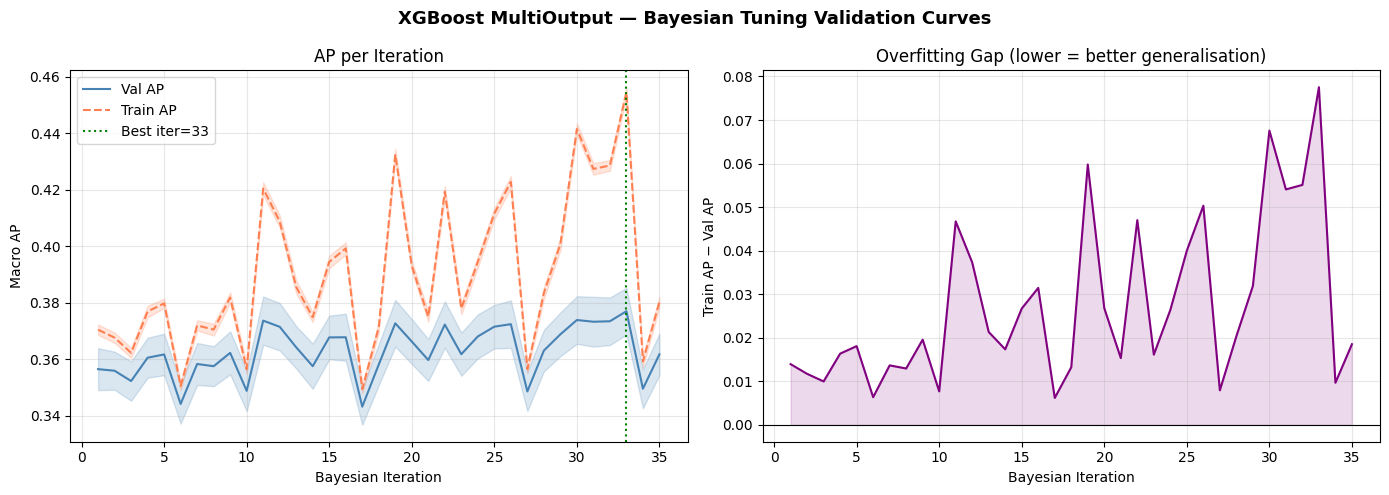

  ✓ Saved: val_curve_XGBoost_MultiOutput.png
  ── Overfitting Summary ──
  Best iter=33  |  Train AP=0.4545  |  Val AP=0.3770  |  Gap=0.0775
  Avg gap=0.0273  |  Max gap=0.0775


In [ ]:
# ════════════════════════════════════════════════════════════════
# TUNING 5 — XGBOOST (MultiOutput)
# ════════════════════════════════════════════════════════════════
print("\nTuning XGBoost (MultiOutput)...")

search_xgb_multi = BayesSearchCV(
    MultiOutputClassifier(XGBClassifier(scale_pos_weight=avg_spw, random_state=42, n_jobs=1, verbosity=0, eval_metric="logloss", device="cuda")),
    {
        "estimator__n_estimators":     Integer(200, 700),
        "estimator__max_depth":        Integer(3, 7),
        "estimator__learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
        "estimator__subsample":        Real(0.5, 1.0),
        "estimator__colsample_bytree": Real(0.5, 1.0),
        "estimator__reg_alpha":        Real(1.0, 10.0, prior="log-uniform"),
        "estimator__reg_lambda":       Real(1.0, 10.0, prior="log-uniform"),
        "estimator__min_child_weight": Integer(20, 100),      
        "estimator__gamma":            Real(0.5, 5.0),  
    },
    n_iter=35, cv=mskf, scoring=macro_ap_scorer,
    return_train_score=True, random_state=42, n_jobs=-1, verbose=0
)
search_xgb_multi.fit(X_train, y_train)
print(f"  Best AP: {search_xgb_multi.best_score_:.4f}  |  Best params: {search_xgb_multi.best_params_}")
plot_validation_curves(search_xgb_multi, "XGBoost MultiOutput")


In [40]:
results_xgb_multi_tuned = evaluate_model_val(search_xgb_multi.best_estimator_, X_val, y_val, reaction_cols, "XGB Multi (Tuned)", mode="multi")


══════════════════════════════════════════════════════════════════════
  XGB Multi (Tuned) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3432 0.7678
  reaction_RASH                       0.4403 0.7656
  reaction_NAUSEA                     0.3490 0.7646
  reaction_DYSPNOEA                   0.3203 0.7546
  reaction_INFECTION                  0.5676 0.8167
  reaction_PSYCHIATRIC_EVENT          0.3920 0.7920
  reaction_FATIGUE                    0.3415 0.7450
  reaction_DEATH                      0.1892 0.8286
  reaction_INJECTION_SITE_REACTION    0.5455 0.8064
  reaction_HEADACHE                   0.3291 0.7358
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3818 0.7777
══════════════════════════════════════════════════════════════════════


In [41]:
joblib.dump(search_xgb_multi.best_estimator_, f"{SAVE_DIR}/xgb_multi_model.pkl")

['/kaggle/working/models/xgb_multi_model.pkl']


Tuning XGBoost (Loop)...
  Best AP: 0.3785  |  Best params: {'colsample_bytree': 0.85, 'gamma': 0.5, 'learning_rate': 0.055393973305281424, 'max_depth': 7, 'min_child_weight': 20, 'n_estimators': 700, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'subsample': 0.9}


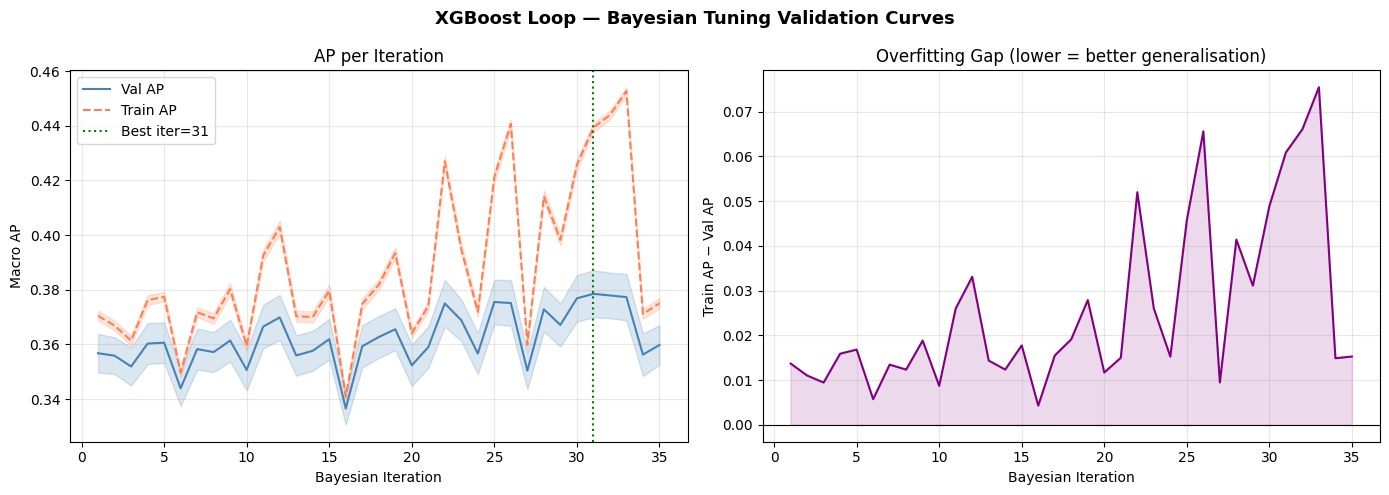

  ✓ Saved: val_curve_XGBoost_Loop.png
  ── Overfitting Summary ──
  Best iter=31  |  Train AP=0.4394  |  Val AP=0.3785  |  Gap=0.0609
  Avg gap=0.0254  |  Max gap=0.0754
  Retraining XGBoost Loop with best params and per-reaction weights...
    ✓ reaction_DIARRHOEA                 
    ✓ reaction_RASH                      
    ✓ reaction_NAUSEA                    
    ✓ reaction_DYSPNOEA                  
    ✓ reaction_INFECTION                 
    ✓ reaction_PSYCHIATRIC_EVENT         
    ✓ reaction_FATIGUE                   
    ✓ reaction_DEATH                     
    ✓ reaction_INJECTION_SITE_REACTION   
    ✓ reaction_HEADACHE                  


In [ ]:
# ════════════════════════════════════════════════════════════════
# TUNING 6 — XGBOOST (Loop)
# ════════════════════════════════════════════════════════════════
print("\nTuning XGBoost (Loop)...")
search_xgb_loop = BayesSearchCV(
    MultiOutputClassifier(XGBClassifier(
        scale_pos_weight = avg_spw,
        random_state     = 42,
        n_jobs           = 1,
        verbosity        = 0,
        eval_metric      = "logloss",  
        device           = "cuda",
    )),
    {
        "estimator__n_estimators":     Integer(200, 700),
        "estimator__max_depth":        Integer(3, 7),            
        "estimator__learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
        "estimator__subsample":        Real(0.6, 0.9),          
        "estimator__colsample_bytree": Real(0.5, 0.85),          
        "estimator__reg_alpha":        Real(1.0, 10.0, prior="log-uniform"), 
        "estimator__reg_lambda":       Real(1.0, 10.0, prior="log-uniform"),
        "estimator__min_child_weight": Integer(20, 100),         
        "estimator__gamma":            Real(0.5, 5.0),           
    },
    n_iter=35, cv=mskf, scoring=macro_ap_scorer,
    return_train_score=True, random_state=42, n_jobs=-1, verbose=0
)
search_xgb_loop.fit(X_train, y_train)
best_xgb_loop_params = {k.replace("estimator__", ""): v for k, v in search_xgb_loop.best_params_.items()}
print(f"  Best AP: {search_xgb_loop.best_score_:.4f}  |  Best params: {best_xgb_loop_params}")
plot_validation_curves(search_xgb_loop, "XGBoost Loop")

# Remove early_stopping_rounds from best params if present
best_xgb_loop_params.pop('early_stopping_rounds', None)

# Retrain loop version with best params + per-reaction weights
print("  Retraining XGBoost Loop with best params and per-reaction weights...")
model_xgb_loop_tuned = {}
for i, col in enumerate(reaction_cols):
    if y_train[:, i].sum() == 0:
        print(f"  ⚠️ Skipping {col} — no positives in train set")
        continue

    clf = XGBClassifier(
        **best_xgb_loop_params,
        scale_pos_weight = scale_pos_weight[col],  # per-label weight
        random_state     = 42,
        n_jobs           = 1,
        verbosity        = 0,
        eval_metric      = "logloss",
        device           = "cuda",
        # no early_stopping_rounds
    )

    clf.fit(X_train, y_train[:, i])  # full X_train, no eval_set
    model_xgb_loop_tuned[col] = clf
    print(f"    ✓ {col:<35}")

In [43]:
results_xgb_loop_tuned = evaluate_model_val(model_xgb_loop_tuned, X_val, y_val, reaction_cols, "XGB Loop (Tuned)",  mode="loop")


══════════════════════════════════════════════════════════════════════
  XGB Loop (Tuned) — Validation Set (AP / AUC only)
══════════════════════════════════════════════════════════════════════
  Reaction                                AP ROC-AUC
  ──────────────────────────────────────────────────
  reaction_DIARRHOEA                  0.3459 0.7701
  reaction_RASH                       0.4406 0.7663
  reaction_NAUSEA                     0.3503 0.7674
  reaction_DYSPNOEA                   0.3207 0.7569
  reaction_INFECTION                  0.5714 0.8199
  reaction_PSYCHIATRIC_EVENT          0.3871 0.7959
  reaction_FATIGUE                    0.3445 0.7485
  reaction_DEATH                      0.1842 0.8255
  reaction_INJECTION_SITE_REACTION    0.5478 0.8075
  reaction_HEADACHE                   0.3291 0.7369
  ──────────────────────────────────────────────────
  AVERAGE (Macro)                     0.3822 0.7795
══════════════════════════════════════════════════════════════════════


In [44]:
joblib.dump(model_xgb_loop_tuned, f"{SAVE_DIR}/xgb_loop_model.pkl")

['/kaggle/working/models/xgb_loop_model.pkl']

In [45]:
# ════════════════════════════════════════════════════════════════
# SECTION 7 — BASE vs TUNED COMPARISON
# ════════════════════════════════════════════════════════════════
print("\n\n" + "═"*70)
print("  BASE vs TUNED — Validation Set (AP / AUC only)")
print("  Use this to confirm tuning improved the model.")
print("═"*70)
print(f"  {'Model':<30} {'AP':>8} {'AUC':>8}")
print("  " + "─"*50)

comparison = {
    "LR (Base)":                results_lr,
    "LR (Tuned)":               results_lr_tuned,
    "Decision Tree (Base)":     results_dt,
    "Decision Tree (Tuned)":    results_dt_tuned,
    "Random Forest (Base)":     results_rf,
    "Random Forest (Tuned)":    results_rf_tuned,
    "XGBoost Multi (Base)":     results_xgb_multi,
    "XGBoost Multi (Tuned)":    results_xgb_multi_tuned,
    "XGBoost Loop (Base)":      results_xgb_loop,
    "XGBoost Loop (Tuned)":     results_xgb_loop_tuned,
    "LightGBM (Base)"    :      results_lgbm,
    "LightGBM (Tuned)"    :     results_lgbm_tuned,
}

for name, res in comparison.items():
    marker = " ←" if "(Tuned)" in name else ""
    print(f"  {name:<30} {res['AP']:>8.4f} {res['ROC-AUC']:>8.4f}{marker}")

print("═"*70)



══════════════════════════════════════════════════════════════════════
  BASE vs TUNED — Validation Set (AP / AUC only)
  Use this to confirm tuning improved the model.
══════════════════════════════════════════════════════════════════════
  Model                                AP      AUC
  ──────────────────────────────────────────────────
  LR (Base)                        0.3014   0.7471
  LR (Tuned)                       0.3020   0.7475 ←
  Decision Tree (Base)             0.3494   0.7638
  Decision Tree (Tuned)            0.3621   0.7623 ←
  Random Forest (Base)             0.3754   0.7794
  Random Forest (Tuned)            0.3812   0.7798 ←
  XGBoost Multi (Base)             0.3798   0.7805
  XGBoost Multi (Tuned)            0.3818   0.7777 ←
  XGBoost Loop (Base)              0.3795   0.7805
  XGBoost Loop (Tuned)             0.3822   0.7795 ←
  LightGBM (Base)                  0.3679   0.7776
  LightGBM (Tuned)                 0.3776   0.7755 ←
══════════════════════════════

In [ ]:
import joblib, json, numpy as np

# Best Param of XGBoost Loop
with open("best_xgb_loop_params.json", "w") as f:
    json.dump(best_xgb_loop_params, f, indent=4)

# The drug column names and reaction column names (for UI construction)
with open("column_names.json", "w") as f:
    json.dump({"drug_cols": drug_cols, "reaction_cols": reaction_cols}, f)

print("Exported!")